In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    LeakyReLU, GlobalMaxPooling2D
)
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Nadam

In [3]:
data_dir = r"E:\ahmed\did it\data"
input_shape=(224, 224, 3)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=input_shape[:2],
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=input_shape[:2],
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 6978 files belonging to 4 classes.
Using 5583 files for training.
Found 6978 files belonging to 4 classes.
Using 1395 files for validation.
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']


In [4]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# تجميد جميع الطبقات
base_model.trainable = False

x = base_model.output
x = GlobalMaxPooling2D()(x)

x = x / 255.0

x = Dense(
    512,
    kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)
)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.5)(x)

x = Dense(
    256,
    kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)
)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.5)(x)

outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [7]:
model.compile(
    optimizer=Nadam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7
)

Epoch 1/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.6760 - loss: 1.0532 - val_accuracy: 0.8194 - val_loss: 0.6412
Epoch 2/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8331 - loss: 0.6587 - val_accuracy: 0.8616 - val_loss: 0.5637
Epoch 3/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.8585 - loss: 0.5890 - val_accuracy: 0.8982 - val_loss: 0.4846
Epoch 4/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.8739 - loss: 0.5542 - val_accuracy: 0.9090 - val_loss: 0.4681
Epoch 5/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.8832 - loss: 0.5241 - val_accuracy: 0.9054 - val_loss: 0.4501
Epoch 6/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.8846 - loss: 0.5152 - val_accuracy: 0.9125 - val_loss: 0.4385
Epoch 7/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.8931 - loss: 0.4943 - val_accuracy: 0.9197 - val_loss: 0.4224


In [12]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Nadam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# إعادة التدريب
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7
)

Epoch 1/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9787 - loss: 0.1375 - val_accuracy: 0.9742 - val_loss: 0.1434
Epoch 2/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.9835 - loss: 0.1203 - val_accuracy: 0.9749 - val_loss: 0.1496
Epoch 3/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9855 - loss: 0.1096 - val_accuracy: 0.9806 - val_loss: 0.1103
Epoch 4/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9907 - loss: 0.0901 - val_accuracy: 0.9806 - val_loss: 0.1090
Epoch 5/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9910 - loss: 0.0814 - val_accuracy: 0.9799 - val_loss: 0.1151
Epoch 6/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9919 - loss: 0.0772 - val_accuracy: 0.9763 - val_loss: 0.1282
Epoch 7/7
175/175 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9914 - loss: 0.0766 - val_accuracy: 0.9849 - val_loss: 0.1001


In [13]:
def predict_and_validate(img, threshold=0.6):

    img = tf.image.resize(img, (224, 224))
    img = BatchNormalization(img)
    img = tf.expand_dims(img, axis=0)

    preds = model.predict(img)
    pred_prob = tf.reduce_max(preds).numpy()
    pred_class = class_names[preds.argmax()]

    if pred_prob < threshold:
        return "Low confidence. Please upload another image."

    return f"Prediction: {pred_class} ({round(pred_prob*100,2)}%)"


In [17]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

44/44 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9849 - loss: 0.1001
Validation Loss: 0.1001
Validation Accuracy: 98.49%


In [18]:
y_true = []
y_pred_classes = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_classes.extend(preds.argmax(axis=1))
    y_true.extend(labels.numpy())

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.99      0.97      0.98       305
     healthy       0.99      0.99      0.99       421
  meningioma       0.96      0.98      0.97       322
   pituitary       0.99      0.99      0.99       347

    accuracy                           0.98      1395
   macro avg       0.98      0.98      0.98      1395
weighted avg       0.99      0.98      0.98      1395



In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_avg = precision_score(y_true, y_pred_classes, average='macro')
recall_avg = recall_score(y_true, y_pred_classes, average='macro')
f1_avg = f1_score(y_true, y_pred_classes, average='macro')

print(f"\nProject-Wide Precision: {precision_avg*100:.2f}%")
print(f"Project-Wide Recall: {recall_avg*100:.2f}%")
print(f"Project-Wide F1 Score: {f1_avg*100:.2f}%")


Project-Wide Precision: 98.47%
Project-Wide Recall: 98.42%
Project-Wide F1 Score: 98.44%


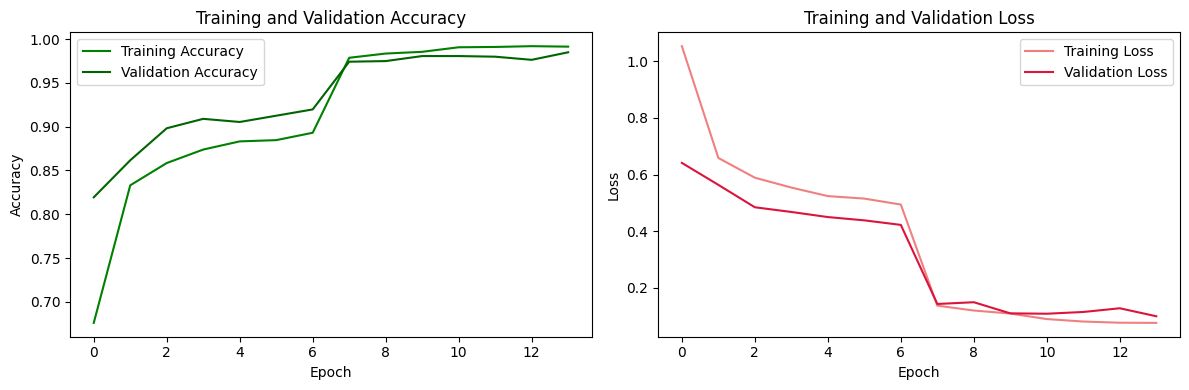

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
# combine histories from both training phases into lists for plotting
acc = []
val_acc = []
loss = []
val_loss = []
for h in (history1, history2):
    if h is None:
        continue
    hist = h.history
    acc.extend(hist.get('accuracy', hist.get('acc', [])))
    val_acc.extend(hist.get('val_accuracy', hist.get('val_acc', [])))
    loss.extend(hist.get('loss', []))
    val_loss.extend(hist.get('val_loss', []))

plt.plot(acc, label='Training Accuracy',color='green')
plt.plot(val_acc, label='Validation Accuracy',color='darkgreen')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='lightcoral')
plt.plot(val_loss, label='Validation Loss', color='crimson')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

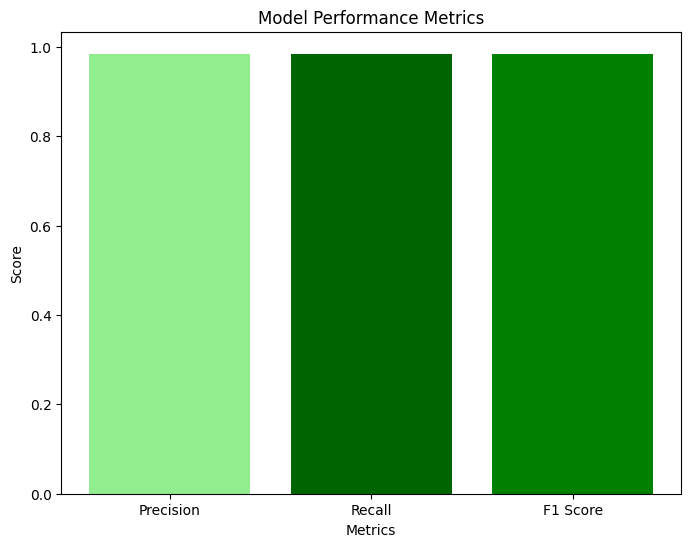

In [38]:
metrics = [precision_avg, recall_avg, f1_avg]
cases = ['Precision', 'Recall', 'F1 Score']
plt.figure(figsize=(8, 6))
plt.bar(cases, metrics, color=['lightgreen', 'darkgreen', 'green'])
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Metrics')
plt.show()


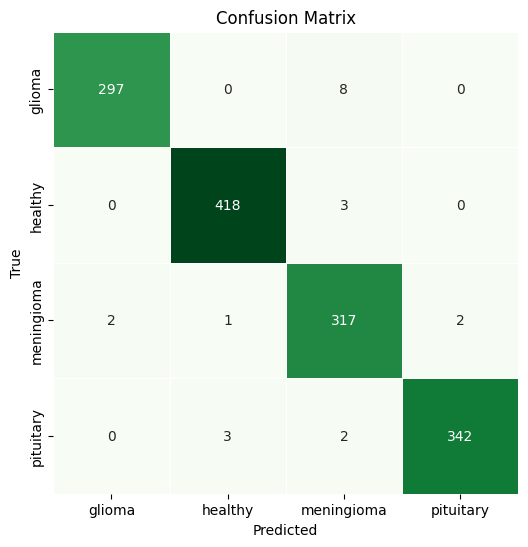

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens", cbar=False, linewidths=0.5)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [49]:
model.save("brain_tumor_model.h5")